<a href="https://colab.research.google.com/github/namharledba/Air-Quality-Prediction-Dashboard-/blob/main/DataAnalysisFile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clean as**


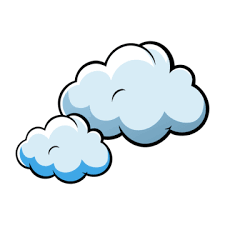

*The File contains Cleaning and Visualization for an Air Quality Dataset*

*you can have access to The Dataset
through the link :* [Dataset](https://www.kaggle.com/datasets/fedesoriano/air-quality-data-set)

Table of content
1. Introduction
2. Data Understanding
3. Data Cleaning
4. EDA
5. Feature Engineering
6. Modeling
7. Evaluation
8. Conclusion


# ***Introduction***

---



# Air Quality Analysis Project

# *This project analyzes air pollution data to understand pollutant behavior and predict air quality indicators using machine learning models.*

In [267]:
#library used in the project
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
import pandas as pd
from google.colab import sheets
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


**libraries for visuallization**

import seaborn as sns

import matplotlib.pyplot as plt

from google.colab import files **upload file from pc to colab notebook**

from google.colab import sheets **used to connect Google Colab with Google Sheets**
import numpy as np **FOR mathmatical operations**

from sklearn.model_selection import train_test_split **Splits dataset into training and testing sets**

from sklearn.preprocessing import StandardScaler **(important for ML models like Linear Regression**


import pandas as pd **for data cleaning and analysis**

from sklearn.linear_model **Basic regression mode**

import LinearRegressionree-based
from sklearn.tree importDecisionTreeRegressor
**tree-based model that splits data into conditions.**

from sklearn.ensemble import RandomForestRegressor
**Ensemble of many decision trees for better accuracy**

from sklearn.ensemble import RandomForestClassifierSame **idea as regression forest but outputs classes (labels)**

from sklearn.metrics import (
)
**this imports regression metrics and classification metrics**

In [268]:
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

Saving AirQualityUCI.csv to AirQualityUCI (1).csv


In [269]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB


## Data Understanding

 CO(GT): Carbon Monoxide concentration
 NOx(GT): Nitrogen Oxides concentration
 NO2(GT): Nitrogen Dioxide concentration
 RH: Relative Humidity
 T: Temperature
 AH: Absolute Humidity

In [270]:
df.head()     #first five rows

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,3/10/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,3/10/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,3/10/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,3/10/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,3/10/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [271]:
df.tail()     #last five rows

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [272]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,NaN,NaN
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,NaN,NaN
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,NaN,NaN
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,NaN,NaN
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,NaN,NaN


# ***Data Cleaning***

---



In [273]:
# Check values equal to -200

mode_value1 = df["Time"][df["Time"] != -200].mode()[0]
df["Time"] = df["Time"].replace(-200, mode_value1)
mode_value2 = df["Date"][df["Date"] != -200].mode()[0]
df["Date"] = df["Date"].replace(-200, mode_value2)

#Replace NaN values with Mode
df["Date"] = df["Date"].fillna(df["Date"].mode()[0])
df["Time"] = df["Time"].fillna(df["Time"].mode()[0])

numeric_cols_with_missing_indicator = [
    'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
    'T', 'RH', 'AH'
]

for col in numeric_cols_with_missing_indicator:
    if col in df.columns:
        mean_val = df[df[col] != -200][col].mean()
        df[col] = df[col].replace(-200, mean_val)

df.dropna(axis=1, how='all', inplace=True)
df.dropna(axis=0, how='all', inplace=True)

df.fillna(df.mean(numeric_only=True), inplace=True)

In [274]:
df.duplicated().sum() # checking for duplication
df.drop_duplicates(inplace=True) #remove duplication
df.isnull().sum() # check after cleaning

,0
Date,0
Time,0
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0


In [275]:
# after cleanning

df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [276]:
df.tail()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
9353,4/4/2005,11:00:00,2.40000,1163.000000,218.811816,11.400000,1027.000000,353.000000,604.000000,179.000000,1264.000000,1269.000000,24.300000,23.700000,0.71190
9354,4/4/2005,12:00:00,2.40000,1142.000000,218.811816,12.400000,1063.000000,293.000000,603.000000,175.000000,1241.000000,1092.000000,26.900000,18.300000,0.64060
9355,4/4/2005,13:00:00,2.10000,1003.000000,218.811816,9.500000,961.000000,235.000000,702.000000,156.000000,1041.000000,770.000000,28.300000,13.500000,0.51390
9356,4/4/2005,14:00:00,2.20000,1071.000000,218.811816,11.900000,1047.000000,265.000000,654.000000,168.000000,1129.000000,816.000000,28.500000,13.100000,0.50280
9357,1/1/2005,0:00:00,2.15275,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.02553


In [277]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9358 entries, 0 to 9357
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9358 non-null   object 
 1   Time           9358 non-null   object 
 2   CO(GT)         9358 non-null   float64
 3   PT08.S1(CO)    9358 non-null   float64
 4   NMHC(GT)       9358 non-null   float64
 5   C6H6(GT)       9358 non-null   float64
 6   PT08.S2(NMHC)  9358 non-null   float64
 7   NOx(GT)        9358 non-null   float64
 8   PT08.S3(NOx)   9358 non-null   float64
 9   NO2(GT)        9358 non-null   float64
 10  PT08.S4(NO2)   9358 non-null   float64
 11  PT08.S5(O3)    9358 non-null   float64
 12  T              9358 non-null   float64
 13  RH             9358 non-null   float64
 14  AH             9358 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.4+ MB


# ***EDA-and-Visualization***

---



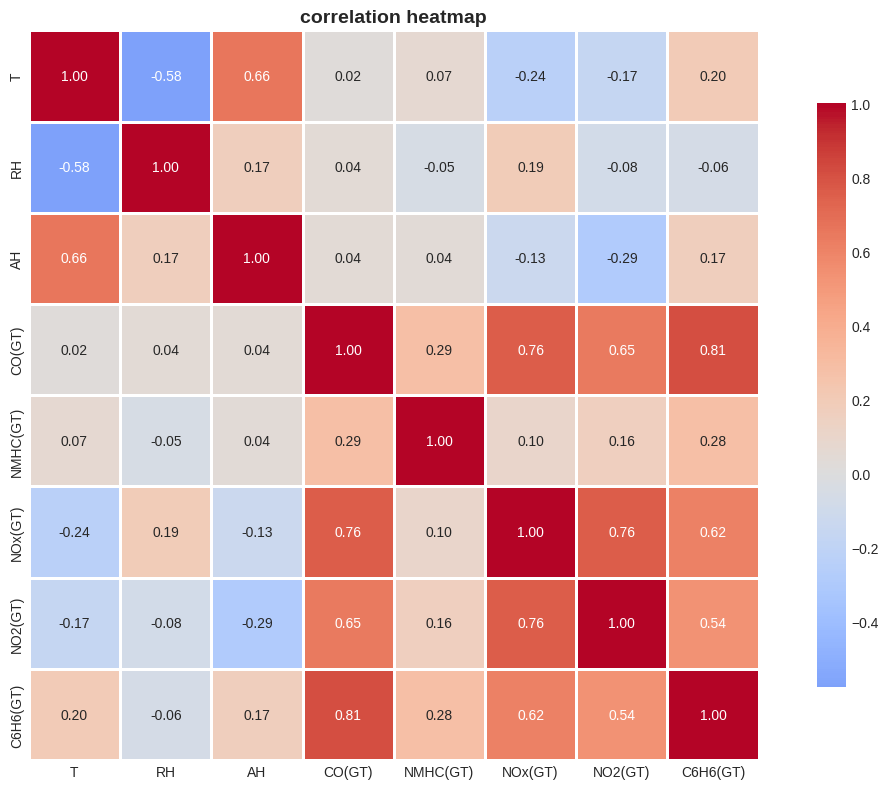

In [278]:
#heatmap
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 8))

columns_to_plot = ['T', 'RH', 'AH', 'CO(GT)', 'NMHC(GT)', 'NOx(GT)', 'NO2(GT)', 'C6H6(GT)']
correlation = df[columns_to_plot].corr()

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('correlation heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **distribution plots**


# **________________________________________________________________________________________________________________________________________________________________**

# **graph for four variables in  air quality dataset**

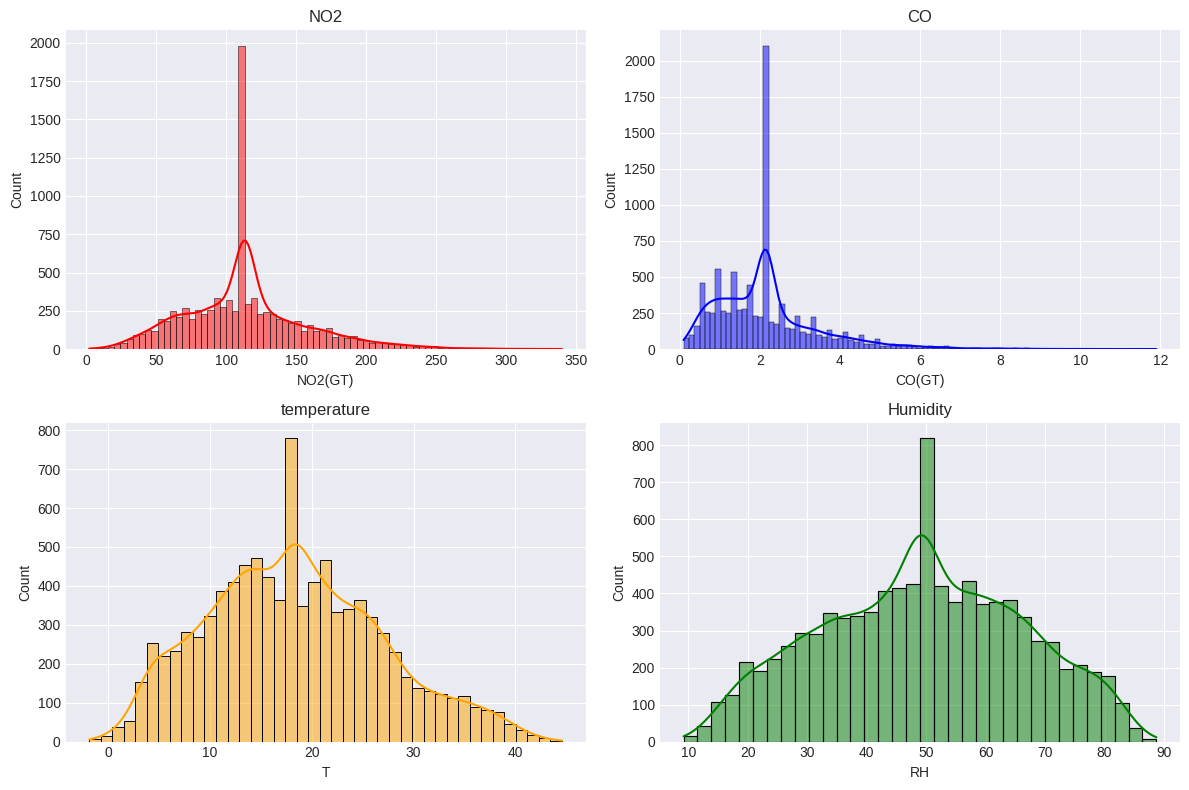

In [279]:
#histogram
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data=df, x='NO2(GT)', kde=True, ax=axes[0, 0], color='red')
axes[0, 0].set_title('NO2')

sns.histplot(data=df, x='CO(GT)', kde=True, ax=axes[0, 1], color='blue')
axes[0, 1].set_title('CO')

sns.histplot(data=df, x='T', kde=True, ax=axes[1, 0], color='orange')
axes[1, 0].set_title('temperature')

sns.histplot(data=df, x='RH', kde=True, ax=axes[1, 1], color='green')
axes[1, 1].set_title('Humidity')

plt.tight_layout()
plt.show()

#Time Series Analysis


# **________________________________________________________________________________________________________________________________________________________________**

# NO2 pollution graph

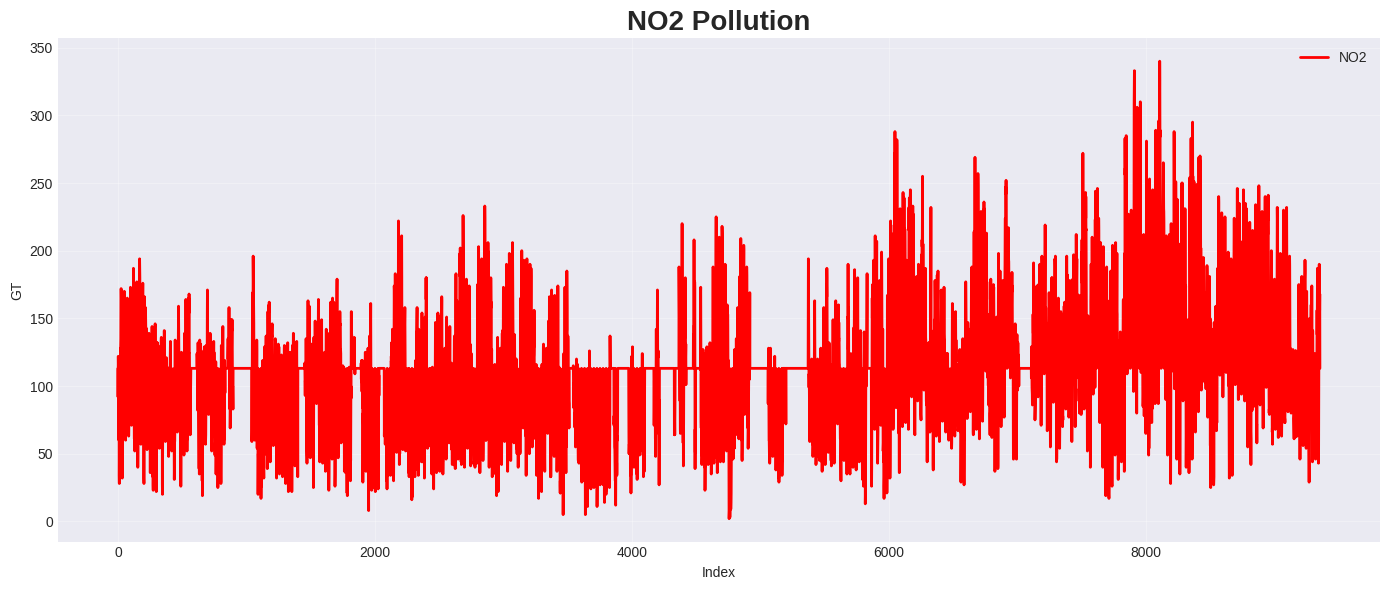

In [280]:
#NO2 Distribution
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x=df.index, y='NO2(GT)', label='NO2', linewidth=2, color = 'red')

plt.title('NO2 Pollution', fontsize=20, fontweight='bold')
plt.xlabel('Index')
plt.ylabel('GT')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **CO pollution graph**

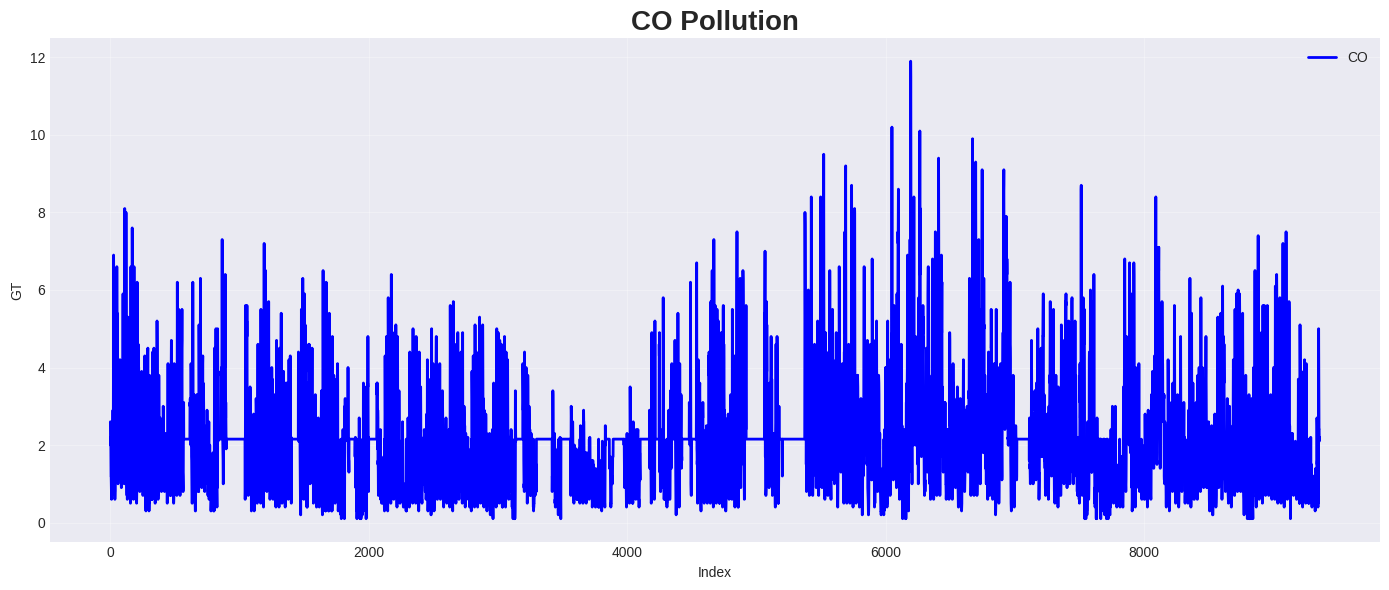

In [281]:
#CO Distribution
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x=df.index, y='CO(GT)', label='CO', linewidth=2,color = 'blue')

plt.title('CO Pollution', fontsize=20, fontweight='bold')
plt.xlabel('Index')
plt.ylabel('GT')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **NOx pollution graph**

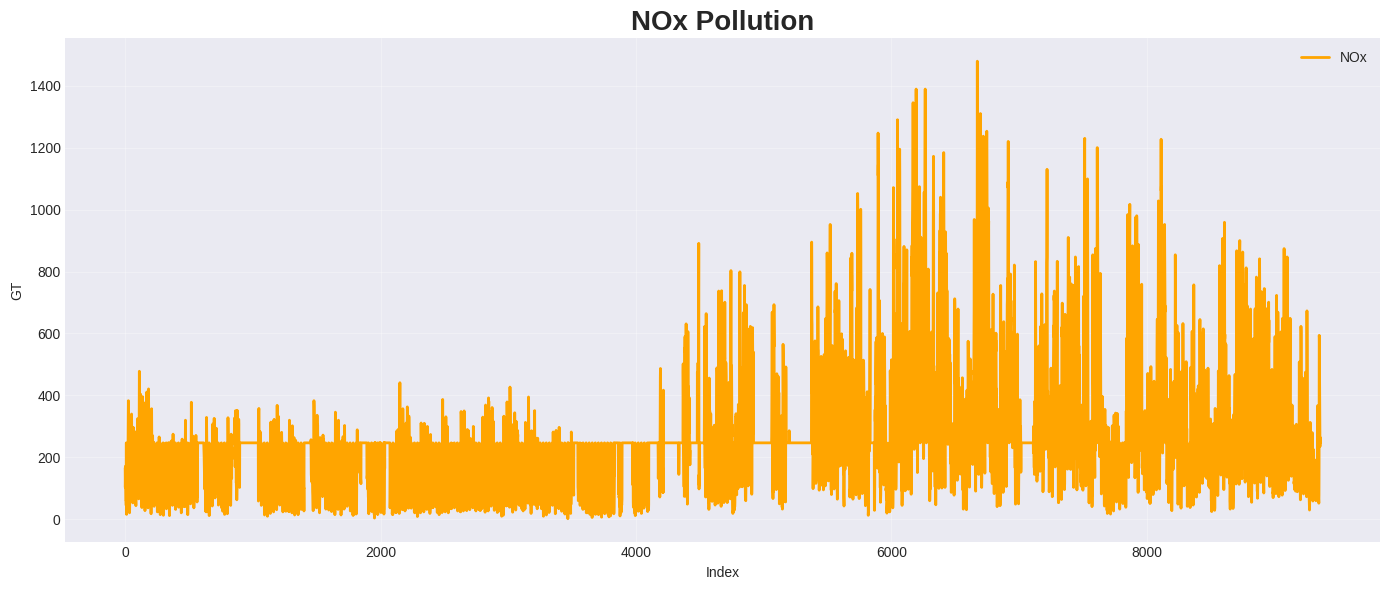

In [282]:
# NOxs distribution
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x=df.index, y='NOx(GT)', label='NOx', linewidth=2,color = 'orange')

plt.title('NOx Pollution', fontsize=20, fontweight='bold')
plt.xlabel('Index')
plt.ylabel('GT')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **correlation between varibales**

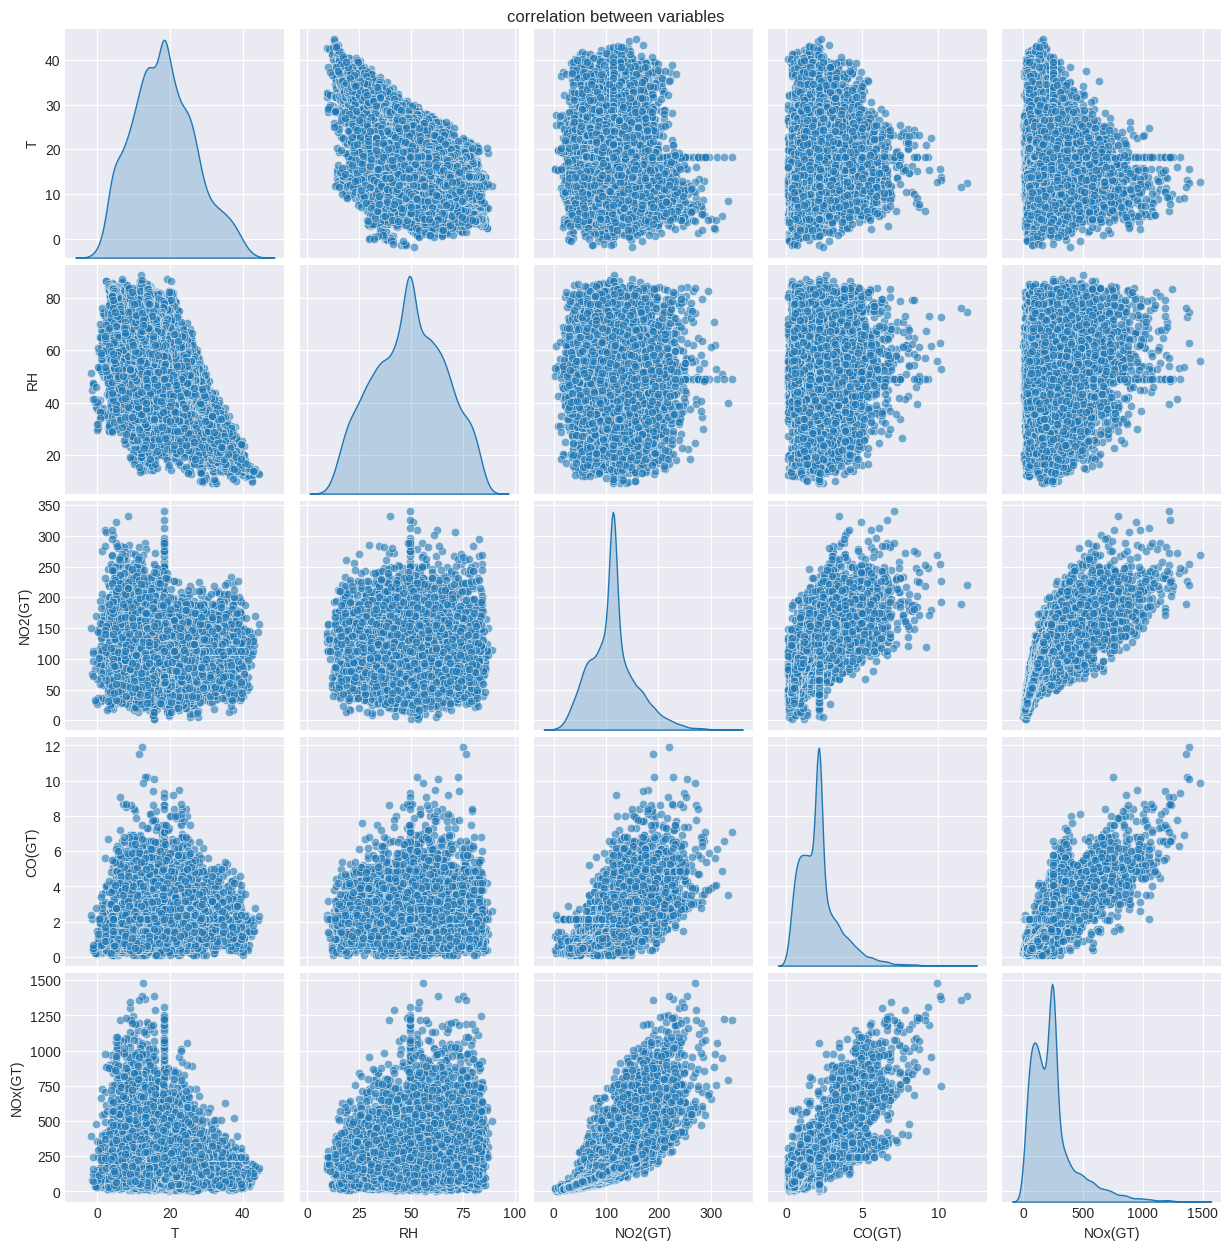

In [283]:
#pair plot
columns = ['T', 'RH', 'NO2(GT)', 'CO(GT)', 'NOx(GT)']

sns.pairplot(df[columns], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('correlation between variables', y=1.00)
plt.show()

# ***The biggest effect is ?***

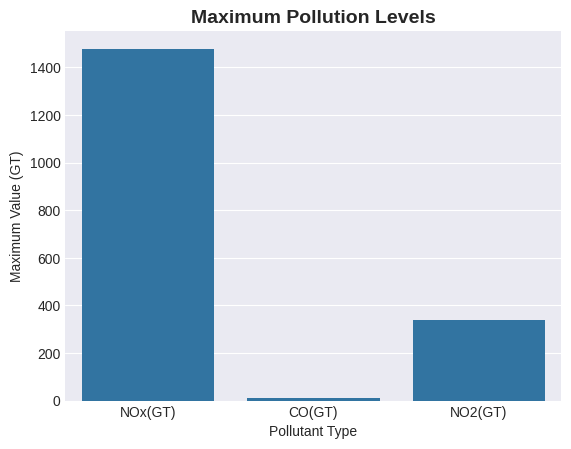

In [284]:
noxmax = df['NOx(GT)'].max()
comax = df['CO(GT)'].max()
no2max = df['NO2(GT)'].max()

max_pollution_data = pd.DataFrame({
    'Pollutant': ['NOx(GT)', 'CO(GT)', 'NO2(GT)'],
    'Max_Value': [noxmax, comax, no2max]
})

sns.barplot(
    x='Pollutant',
    y='Max_Value',
    data=max_pollution_data
)

plt.title('Maximum Pollution Levels', fontsize=14, fontweight='bold')
plt.xlabel('Pollutant Type')
plt.ylabel('Maximum Value (GT)')
plt.show()

#although co is not the heighest but
CO (carbon monoxide) reduces the blood's ability to carry oxygen by binding to hemoglobin more strongly than oxygen.
This leads to headaches, dizziness, weakness, and confusion at low to moderate exposure levels.
Higher exposure can cause chest pain, fainting, and can be life-threatening by starving vital organs of oxygen.
Long-term or repeated exposure can harm the heart and brain, especially in people with existing health problems

# ***Comparison Between the biggest causes***

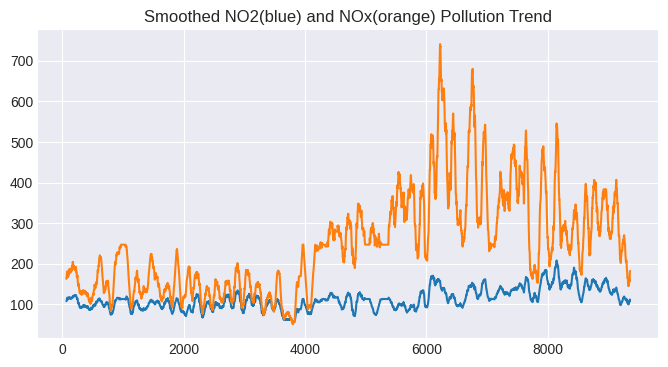

In [285]:
df['NO2(GT)'].rolling(100).mean(),
df['NOx(GT)'].rolling(100).mean()
plt.figure(figsize=(8,4))
plt.plot(
    df.index,

    df['NO2(GT)'].rolling(70).mean(),
    df['NOx(GT)'].rolling(70).mean(),

)

plt.title('Smoothed NO2(blue) and NOx(orange) Pollution Trend')

plt.show()

#WHAT IF NO₂ and NOx BECOME MORE THAN NEEDED
 irritate the lungs, causing coughing, wheezing, and shortness of breath.
They can trigger or worsen asthma and other breathing problems.
Long-term exposure damages lung function and increases risk of chronic respiratory disease.
They also weaken immunity in the airways, making infections more likely.

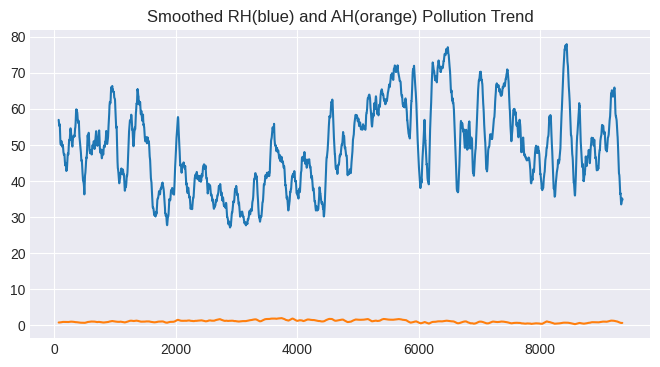

In [286]:
df['RH'].rolling(50).mean(),
df['AH'].rolling(50).mean()
plt.figure(figsize=(8,4))
plt.plot(
    df.index,

    df['RH'].rolling(70).mean(),
    df['AH'].rolling(70).mean()

)

plt.title('Smoothed RH(blue) and AH(orange) Pollution Trend')

plt.show()

#**WHAT IF RH IS WAY HIGHER THAT AH**
Increased mold exposure can trigger allergies, asthma attacks, and respiratory irritation.
Constant damp air may worsen sinus problems and increase risk of throat and lung infections.
High humidity environments can make breathing feel heavier, especially for people with asthma or COPD.
Ongoing exposure to damp conditions can also promote headaches, fatigue, and general discomfort

# _______________________________________________________________________________

# **Feature engineering**
 :CO(GT) and NO2(GT) and NOx(GT) was selected as the  major target variables because carbon monoxide,Nitrogen Dioxide and Nitrogen Oxides concentration is a major air pollutant and strongly reflects environmental air quality but ofcourse there are other indicators that effects that we consider too

---



In [287]:
#TH E rule
def air_quality_category(row):

    score = 0

    if row['CO(GT)'] > 2:
        score += 1

    if row['NO2(GT)'] > 80:
        score += 1

    if row['NOx(GT)'] > 150:
        score += 1

    if row['C6H6(GT)'] > 10:
        score += 1

    if row['RH'] > 60:
        score += 1

    if score <= 1:
        return "Good"

    elif score <= 3:
        return "Moderate"

    else:
        return "Poor"


df['Air_Quality'] = df.apply(
    air_quality_category,
    axis=1
)

In [288]:
def detect_risk_conditions(row):
    risks = []
    if row['CO(GT)'] > 2:    risks.append(f"CO elevated: {row['CO(GT)']:.2f} (limit: 2)")
    if row['NO2(GT)'] > 80:  risks.append(f"NO2 elevated: {row['NO2(GT)']:.2f} (limit: 80)")
    if row['NOx(GT)'] > 150: risks.append(f"NOx elevated: {row['NOx(GT)']:.2f} (limit: 150)")
    if row['C6H6(GT)'] > 10: risks.append(f"Benzene elevated: {row['C6H6(GT)']:.2f} (limit: 10)")
    if row['RH'] > 60:       risks.append(f"Humidity high: {row['RH']:.2f}% (limit: 60%)")
    return risks or ["No risk conditions detected"]

# test on a sample row
sample = df.iloc[0]
print(f"Air Quality: {sample['Air_Quality']}")
for r in detect_risk_conditions(sample): print(f"  ⚠ {r}")

Air Quality: Poor
  ⚠ CO elevated: 2.60 (limit: 2)
  ⚠ NO2 elevated: 113.00 (limit: 80)
  ⚠ NOx elevated: 166.00 (limit: 150)
  ⚠ Benzene elevated: 11.90 (limit: 10)


# **Modeling**
# in summary modeling is:
 input (features) - some known information
Output (target) - the value you want to predict

In [289]:
#REGRESSION PROBLEM SETUP
X_reg = df.drop(['CO(GT)', 'Air_Quality', 'Date', 'Time'], axis=1)

y_reg = df[['CO(GT)']]

In [290]:
#Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)


Splits data

80% training
20% testing:
 why this percantage? becuase it is the best by test

# *note random_state=42 just to ensures reproducibility

In [291]:
#scaling
scaler_reg = StandardScaler()

X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)

**Learns mean and std from training data**
**Transforms training data**
**Uses SAME scaling learned from training**

In [292]:
#linear regression modek
linear_model = LinearRegression()

linear_model.fit(X_train_reg, y_train_reg)

y_pred_linear = linear_model.predict(X_test_reg)

print("\nlinear regression results")


linear regression results


R2Score: 0.8095431273776663
Mae: 0.396124192030394
Mse: 0.36065036596885597


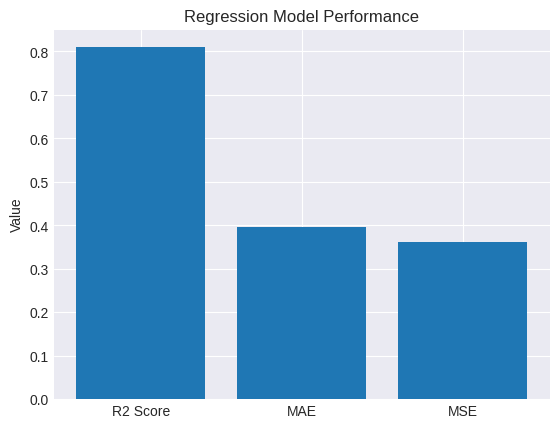

In [293]:
print("R2Score:", r2_score(y_test_reg, y_pred_linear))
print("Mae:", mean_absolute_error(y_test_reg, y_pred_linear))
print("Mse:", mean_squared_error(y_test_reg, y_pred_linear))
metrics = ['R2 Score', 'MAE', 'MSE']
values = [
    r2_score(y_test_reg, y_pred_linear),
    mean_absolute_error(y_test_reg, y_pred_linear),
    mean_squared_error(y_test_reg, y_pred_linear)
]

plt.bar(metrics, values)
plt.title("Regression Model Performance")
plt.ylabel("Value")
plt.show()

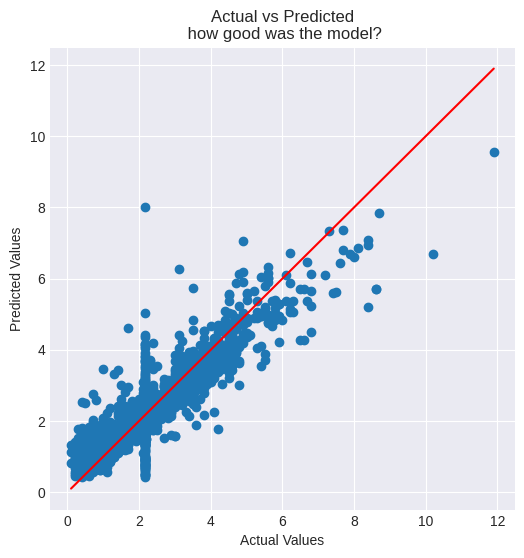

In [294]:
y_test = np.array(y_test_reg).flatten()
y_pred = np.array(y_pred_linear).flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted\n how good was the model?")

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r')

plt.show()

***The red diagonal line represents perfect predictions (predicted = actual). What you’re seeing:***

# Most points cluster around the line, especially in the lower-to-mid range (roughly 0–5). That means the model is learning the general relationship correctly

# decision TREE regressor

In [295]:
dt_model = DecisionTreeRegressor(random_state=42)
#Creates tree model that splits data into rules
dt_model.fit(X_train_reg, y_train_reg)#some rule of our own to do a specific things
y_pred_dt = dt_model.predict(X_test_reg)#Predicts values using tree paths



decision tree results
R2 Score: 0.732679201396824
Mae: 0.4258038627547599
Mse: 0.5062003934008573


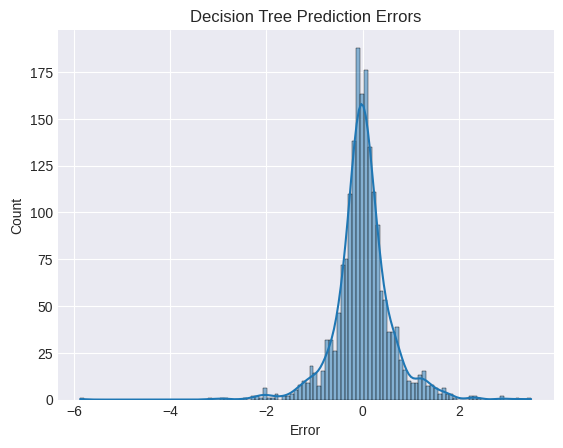

In [296]:
#printing decision tree results
print("\ndecision tree results")
print(
    "R2 Score:",
    r2_score(y_test_reg, y_pred_dt)
)

print(
    "Mae:",
    mean_absolute_error(
        y_test_reg,
        y_pred_dt
    )
)

print(
    "Mse:",
    mean_squared_error(
        y_test_reg,
        y_pred_dt
    )
)

errors = y_test - y_pred

sns.histplot(errors, kde=True)
plt.title("Decision Tree Prediction Errors")
plt.xlabel("Error")
plt.show()

# *Random forest regressor*

In [297]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
#builds 100 decision trees
#prediction is the   average of all trees
rf_model.fit(X_train_reg, y_train_reg)#trains all trees
y_pred_rf = rf_model.predict(X_test_reg)#Predicts using ensemble averaging




/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().




random forest results
R2 Score: 0.8606831379437039
MAE: 0.31746603980111765
MSE: 0.2638113111616005


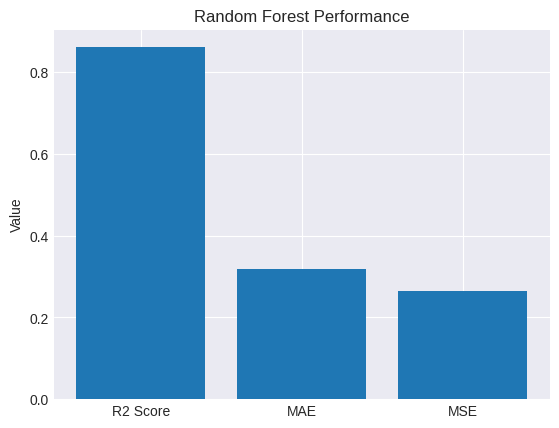

In [298]:
#printing result
print("\nrandom forest results")

print(
    "R2 Score:",
    r2_score(y_test_reg, y_pred_rf)
)

print(
    "MAE:",
    mean_absolute_error(
        y_test_reg,
        y_pred_rf
    )
)

print(
    "MSE:",
    mean_squared_error(
        y_test_reg,
        y_pred_rf
    )
)
metrics = ['R2 Score', 'MAE', 'MSE']
values = [
    r2_score(y_test_reg, y_pred_rf),
    mean_absolute_error(y_test_reg, y_pred_rf),
    mean_squared_error(y_test_reg, y_pred_rf)
]

plt.bar(metrics, values)
plt.title("Random Forest Performance")
plt.ylabel("Value")
plt.show()

# CLASSIFICATION *SETUP*

In [299]:

X_cls = df.drop( ['Air_Quality', 'CO(GT)', 'NO2(GT)', 'Date', 'Time'], axis=1 )
#removes label and datetime

#Target
y_cls = df['Air_Quality']
#prediction res

In [300]:
#train test Split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42
)

In [301]:
# Feature Scaling
scaler_cls = StandardScaler()

X_train_cls = scaler_cls.fit_transform(
    X_train_cls
)

X_test_cls = scaler_cls.transform(
    X_test_cls
)


# RANDOM FOREST **CLASSIFIER**





In [302]:
classifier = RandomForestClassifier(
    n_estimators=50,
    max_depth=4,
    min_samples_split=8,
    min_samples_leaf=4,
    random_state=42
)
#100 trees voting on class
classifier.fit(X_train_cls, y_train_cls)
#Learns classification patterns
y_pred_cls = classifier.predict(X_test_cls)
#predicts air quality category

## Reveiw **results**

In [303]:
#Accuracy
accuracy = accuracy_score(y_test_cls, y_pred_cls)

print("Classification Accuracy:", accuracy * 100, "%")

Classification Accuracy: 88.03418803418803 %


In [304]:
#Details

report = classification_report(y_test_cls, y_pred_cls, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report.style.background_gradient()

,precision,recall,f1-score,support
Good,0.867754,0.961847,0.912381,498.000000
Moderate,0.833841,0.826284,0.830046,662.000000
Poor,0.936747,0.873596,0.904070,712.000000
accuracy,0.880342,0.880342,0.880342,0.880342
macro avg,0.879447,0.887242,0.882165,1872.000000
weighted avg,0.882002,0.880342,0.880103,1872.000000


# **How Well The Model was trained ?**

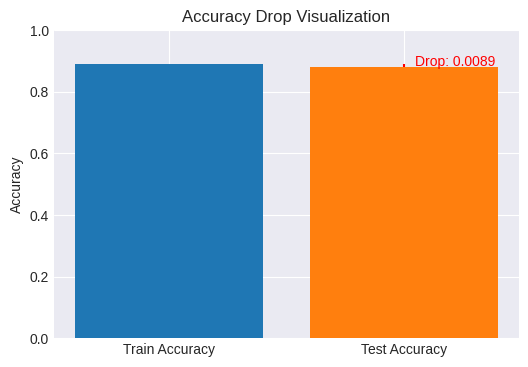

In [305]:
train_acc = classifier.score(X_train_cls, y_train_cls)
test_acc = classifier.score(X_test_cls, y_test_cls)

plt.figure(figsize=(6,4))

plt.bar(['Train Accuracy'], [train_acc], label='Train')
plt.bar(['Test Accuracy'], [test_acc], label='Test')

# draw difference line
plt.vlines(x=1, ymin=test_acc, ymax=train_acc, colors='red', linestyles='dashed')

plt.text(1.05, (train_acc+test_acc)/2,
         f"Drop: {train_acc-test_acc:.4f}",
         color='red')

plt.ylim(0, 1)
plt.title("Accuracy Drop Visualization")
plt.ylabel("Accuracy")

plt.show()

# **what worked better in this model ?**

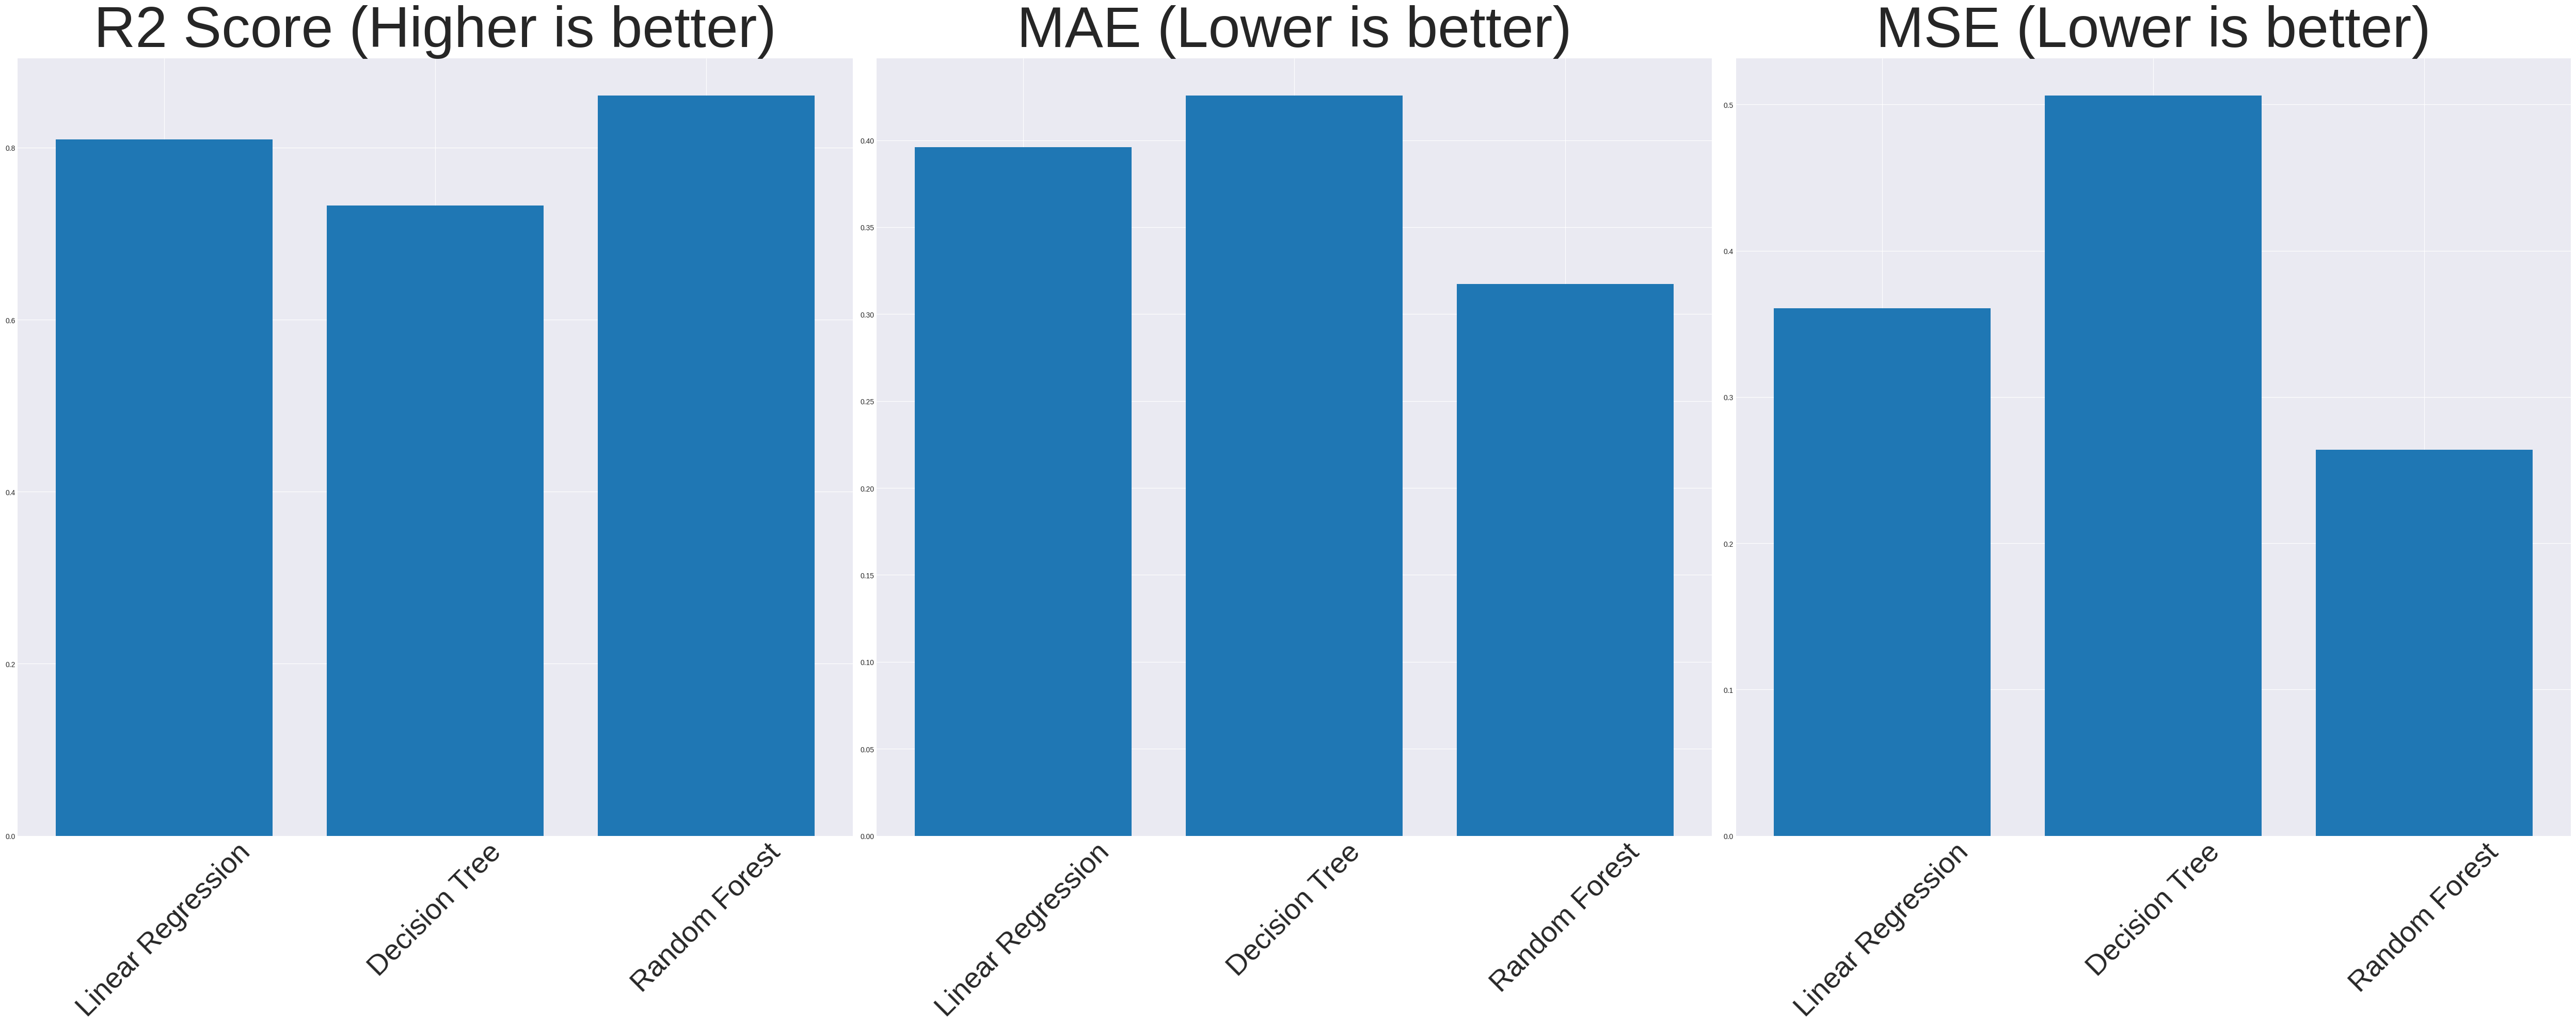

In [306]:

models = ['Linear Regression', 'Decision Tree', 'Random Forest']

r2 = [
    r2_score(y_test_reg, y_pred_linear),
    r2_score(y_test_reg, y_pred_dt),
    r2_score(y_test_reg, y_pred_rf)
]

mae = [
    mean_absolute_error(y_test_reg, y_pred_linear),
    mean_absolute_error(y_test_reg, y_pred_dt),
    mean_absolute_error(y_test_reg, y_pred_rf)
]

mse = [
    mean_squared_error(y_test_reg, y_pred_linear),
    mean_squared_error(y_test_reg, y_pred_dt),
    mean_squared_error(y_test_reg, y_pred_rf)
]

#  BIGGER FIGURE SIZE
fig, axs = plt.subplots(1, 3, figsize=(50, 20))

# R2
axs[0].bar(models, r2)
axs[0].set_title("R2 Score (Higher is better)", fontsize=80)
axs[0].tick_params(axis='x', rotation=45, labelsize=40)

# MAE
axs[1].bar(models, mae)
axs[1].set_title("MAE (Lower is better)", fontsize=80)
axs[1].tick_params(axis='x', rotation=45, labelsize=40)

# MSE
axs[2].bar(models, mse)
axs[2].set_title("MSE (Lower is better)", fontsize=80)
axs[2].tick_params(axis='x', rotation=45, labelsize=40)

plt.tight_layout()
plt.show()

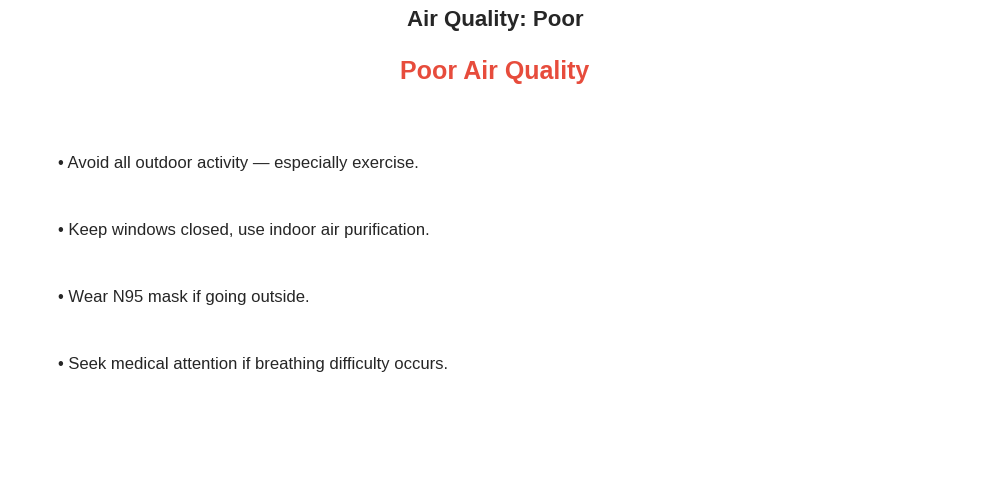

In [307]:
def get_recommendations(air_quality_label):
    recs = {
        'Good': [
            "Conditions are safe — outdoor activities are fine.",
            "Good time for ventilation — open windows."
        ],
        'Moderate': [
            "Sensitive groups (children, elderly, asthmatics) should limit outdoor exposure.",
            "Avoid prolonged exercise near traffic.",
            "Keep windows partially closed during peak hours."
        ],
        'Poor': [
            "Avoid all outdoor activity — especially exercise.",
            "Keep windows closed, use indoor air purification.",
            "Wear N95 mask if going outside.",
            "Seek medical attention if breathing difficulty occurs."
        ]
    }
    colors = {
        'Good': "#2ecc71",
        'Moderate': "#f1c40f",
        'Poor': "#e74c3c"
    }

    items = recs[air_quality_label]

    plt.figure(figsize=(10, 5))
    plt.title(f"Air Quality: {air_quality_label}", fontsize=16, fontweight='bold')


    plt.axis("off")


    plt.text(
        0.5, 0.9,
        f"{air_quality_label} Air Quality",
        ha="center",
        fontsize=18,
        fontweight="bold",
        color=colors[air_quality_label]
    )


    for i, r in enumerate(items):
        plt.text(
            0.05,
            0.7 - i*0.15,
            f"• {r}",
            fontsize=12
        )

    plt.tight_layout()
    plt.show()

# test
get_recommendations(df['Air_Quality'].iloc[0])

In [308]:
forecast_df = df.copy()

forecast_df['Datetime'] = pd.to_datetime(
    forecast_df['Date'] + ' ' + forecast_df['Time']
)

forecast_df = forecast_df.sort_values('Datetime')


forecast_df['Month'] = forecast_df['Datetime'].dt.month
forecast_df['Day'] = forecast_df['Datetime'].dt.day
forecast_df['Hour'] = forecast_df['Datetime'].dt.hour
forecast_df['DayOfWeek'] = forecast_df['Datetime'].dt.dayofweek

In [309]:

forecast_df['T_lag_24'] = forecast_df['T'].shift(24)
forecast_df['T_lag_48'] = forecast_df['T'].shift(48)
forecast_df['T_lag_168'] = forecast_df['T'].shift(168)


forecast_df['Future_T'] = forecast_df['T'].shift(-24)

forecast_df.dropna(inplace=True)

In [310]:
X_temp = forecast_df[
    ['Month','Day','Hour','DayOfWeek',
     'T_lag_24','T_lag_48','T_lag_168']
]

y_temp = forecast_df['Future_T']

temp_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

temp_model.fit(X_temp, y_temp)

RandomForestRegressor(n_estimators=300, random_state=42)

In [311]:
X_air = X_temp
y_air = forecast_df['Air_Quality']

air_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

air_model.fit(X_air, y_air)

RandomForestClassifier(n_estimators=300, random_state=42)

In [312]:
last_row = forecast_df.iloc[-1]

feature_cols = [
    'Month','Day','Hour','DayOfWeek',
    'T_lag_24','T_lag_48','T_lag_168'
]

features = last_row[feature_cols].to_frame().T.copy()

In [313]:
future_results = []

for week in range(1, 5):


    temp_pred = temp_model.predict(features)[0]


    probs = air_model.predict_proba(features)[0]
    pred_class = air_model.classes_[np.argmax(probs)]
    confidence = np.max(probs)


    if pred_class == "Good":
        status = "SAF"
    elif pred_class == "Moderate":
        status = "RISKY"
    else:
        status = "DANGEROUS"

    future_results.append([
        f"Week {week}",
        round(temp_pred, 1),
        pred_class,
        round(confidence, 2),
        status
    ])


    features['T_lag_168'] = features['T_lag_48']
    features['T_lag_48'] = features['T_lag_24']
    features['T_lag_24'] = temp_pred

    features['Hour'] = (features['Hour'] + 24) % 24
    features['Day'] = features['Day'] + 1

In [314]:
results_df = pd.DataFrame(
    future_results,
    columns=["Week", "Temperature", "Air Quality", "Confidence", "Status"]
)

results_df

,Week,Temperature,Air Quality,Confidence,Status
0,Week 1,26.1,Good,0.74,SAF
1,Week 2,25.9,Moderate,0.49,RISKY
2,Week 3,23.1,Moderate,0.49,RISKY
3,Week 4,23.7,Good,0.64,SAF


In [315]:
import plotly.express as px


plot_df = results_df.copy()


color_map = {
    "Good": "green",
    "Moderate": "orange",
    "Bad": "red"
}

plot_df["Color"] = plot_df["Air Quality"].map(color_map)

fig = px.line(
    plot_df,
    x="Week",
    y="Temperature",
    title=" Temperature Forecast (Next Weeks)",
    markers=True
)


fig.add_scatter(
    x=plot_df["Week"],
    y=plot_df["Temperature"],
    mode="markers",
    marker=dict(
        size=12,
        color=plot_df["Color"]
    ),
    name="Air Quality Status"
)

fig.update_layout(
    template="plotly_dark",
    xaxis_title="Time",
    yaxis_title="Temperature (°C)",
    hovermode="x unified"
)

fig.show()

In [316]:
fig2 = px.bar(
    plot_df,
    x="Week",
    y="Confidence",
    color="Air Quality",
    title="🌫️ Air Quality Confidence Over Time",
    text="Air Quality"
)

fig2.update_layout(template="plotly_dark")
fig2.show()

In [317]:
model_T = RandomForestRegressor(n_estimators=300, random_state=42)
model_T.fit(X_temp, y_temp)

RandomForestRegressor(n_estimators=300, random_state=42)

In [318]:
feature_names = [
    'Month','Day','Hour','DayOfWeek',
    'T_lag_24','T_lag_48','T_lag_168'
]

importances = model_T.feature_importances_

cause_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

cause_df

,Feature,Importance
4,T_lag_24,0.772162
6,T_lag_168,0.050884
5,T_lag_48,0.050548
1,Day,0.049098
0,Month,0.035825
3,DayOfWeek,0.021205
2,Hour,0.020279


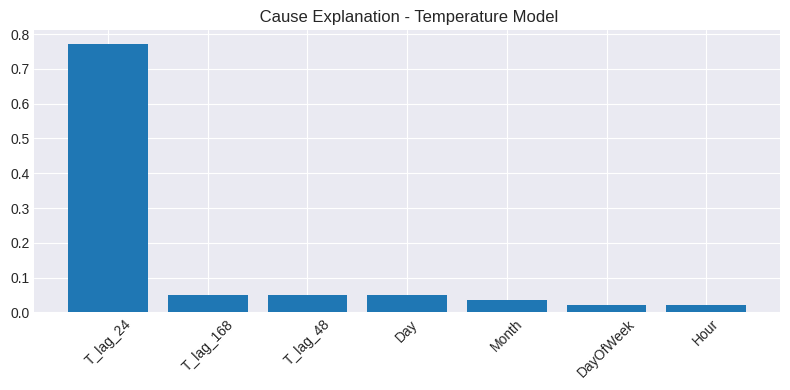

In [319]:
# دي عشان نعرف اي اكتر حاجه اعتمد عليها الموديل فتوقع
plt.figure(figsize=(8,4))
plt.bar(cause_df["Feature"], cause_df["Importance"])
plt.title(" Cause Explanation - Temperature Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

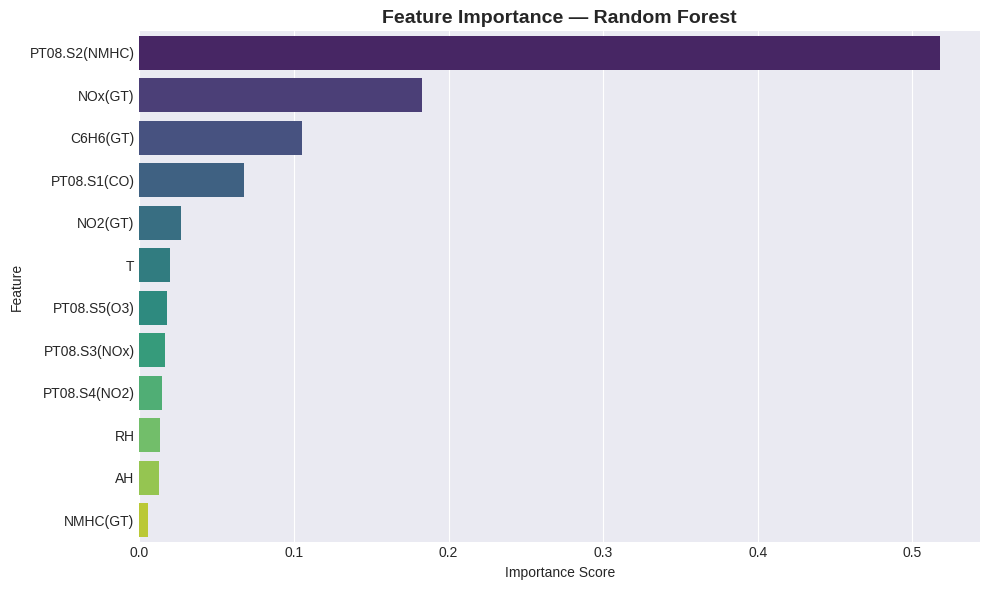

In [320]:
importance_df = pd.DataFrame({
    'Feature': X_reg.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# **Conclusion**



- Random Forest achieved the best performance
- CO strongly correlates with NOx
- Feature engineering improved prediction quality

Future Work:
- Hyperparameter tuning
- Better classification labels
- Time-series forecasting
- Far predection limit
-stronger model works for diffrent data